
=== Annual Savings from Cleaning Dark Data ===
                           Saving Type                              Value ($)
               Storage Cost Eliminated                                 1200.0
         Search Productivity Recovered                                 156000
Breach Cost Avoided (if breach occurs)                               157200.0
        Risk Severity Reduction Factor 50% worse outcome if dark data present
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------

=== Breach components ===
           Breach Cost Component  Amount ($)                     Basis
                Storage Exposure      1200.0            60 TB × $20/TB
               Incident Response    250000.0   Incident team, 2 months
                    Notification    150000.0 Legal + customer mailings
                   Lost Business    750000.0   3 

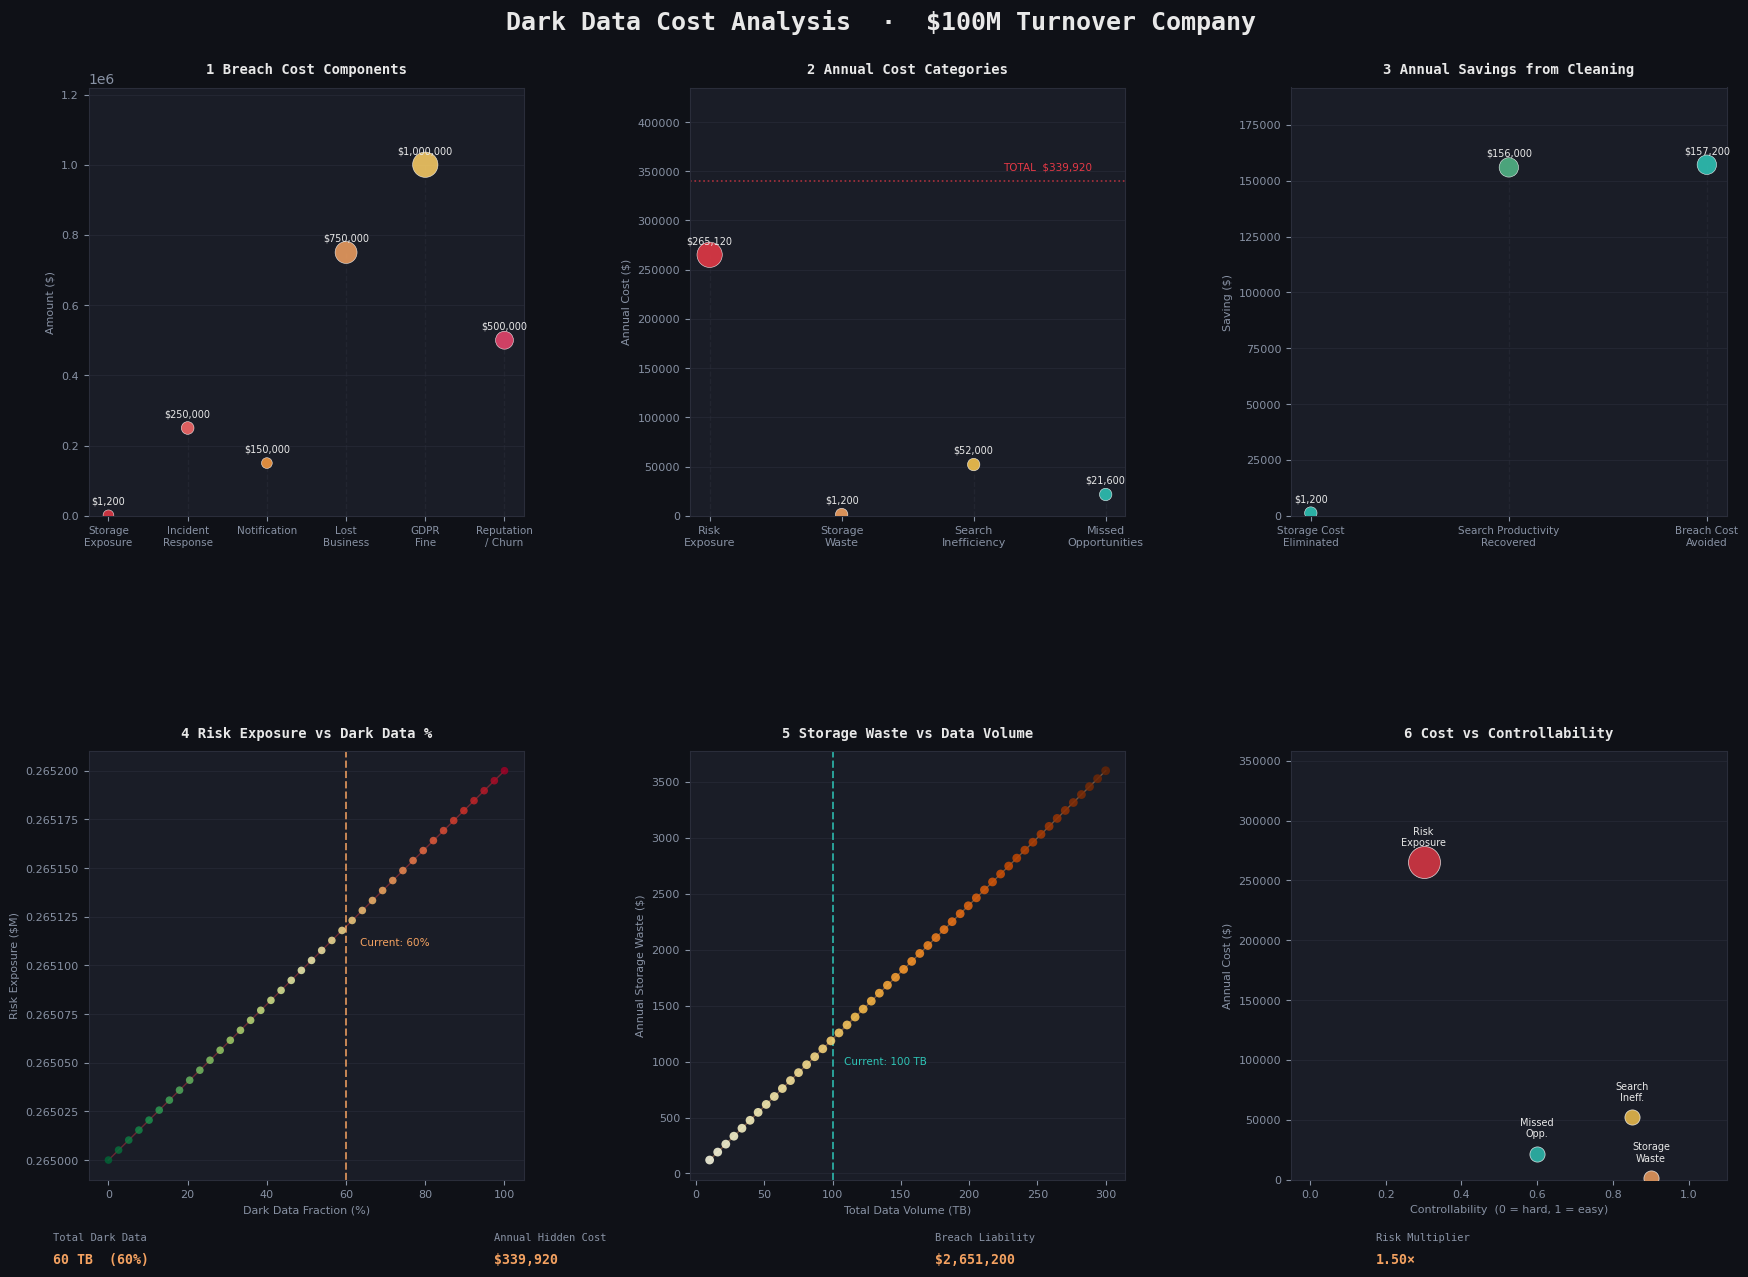

dark data risk_scatter.png


In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import sklearn
import math

#Adding hypothetical project inputs for a 100M Company turnover

data_tb = 100 #total data volume in tb
records_per_tb = 250000 #number of records
f_dark = 0.6 #60% dark data
cost_store_data = 20 #storage cost in $/perTB/year
breach_base = 0.1 #
breach_dark = 0.2 #2x risk
t_search_hr = 2 #hours/week/team member
rate = 50 #$/hr
n_team = 10 
n_projects = 12 #projects/year
v_insight = 10000 #saved per insight as per the project costs in $
incident_response  = 250_000    # Incident team, 2 months
notification_cost  = 150_000    # legal + customer mailings
lost_business      = 750_000    # 3 months project delays
GDPR_fine          = 0.01 * 100_000_000  # 1% of $100M turnover → $1,000,000
reputation_cost    = 500_000    # customer churn estimate

#Calculate hidden costs
storage_exposure = f_dark * data_tb * cost_store_data #storage cost of keeping dark data

search_waste = t_search_hr * rate * n_team * 52 #lost productivity cost

search_breach_cost = search_waste * 3 #amplified productivity cost during a data breach

dark_records = f_dark * data_tb * records_per_tb #total number of individual data records

risk_multiplier = 0.2 / 0.1 * 0.75 #severity increase factor keeping 0.75 adjustments

l_breach = (storage_exposure + incident_response + notification_cost +
            lost_business + GDPR_fine + reputation_cost)

#calculate annual savings
annual_savings = pd.DataFrame({
    'Saving Type': ['Storage Cost Eliminated', 'Search Productivity Recovered','Breach Cost Avoided (if breach occurs)','Risk Severity Reduction Factor'],
    'Value ($)': [storage_exposure, search_breach_cost, storage_exposure + search_breach_cost, f"{(risk_multiplier - 1) * 100:.0f}% worse outcome if dark data present"]
})
print("\n=== Annual Savings from Cleaning Dark Data ===")
print(annual_savings.to_string(index=False))
print("-" * 100)   # Breaker
print("-" * 100)   # Breaker


#calculate breach componenets

breach_components = pd.DataFrame({
    'Breach Cost Component': ['Storage Exposure', 'Incident Response',  'Notification', 'Lost Business', 'GDPR Fine (1% of $100M turnover)',
        'Reputation / Churn', 'TOTAL (l_breach)'  ],
    'Amount ($)': [storage_exposure, incident_response, notification_cost, lost_business, GDPR_fine, reputation_cost, l_breach ],
    'Basis': ['60 TB × $20/TB', 'Incident team, 2 months', 'Legal + customer mailings', '3 months project delays','1% of company turnover',
        'Customer churn estimate','' ]
})
print("\n=== Breach components ===")
print(breach_components.to_string(index=False))


print("-" * 100)
#calculate risk, Inefficiency, missed opportunity
r_risk = (breach_dark - breach_base) * l_breach #
i_storage = f_dark * data_tb *cost_store_data #
i_search = t_search_hr * rate * n_team * 52 #
i_total = i_storage + i_search #
o_opportunity = n_projects * v_insight * f_dark * 0.3 #30% insight capture rate
total_cost = r_risk + i_total + o_opportunity 

print("-" * 100)  # Breaker

# Results table
results = pd.DataFrame({
    'Cost Type': ['Risk Exposure', 'Storage Waste', 'Search Inefficiency', 'Missed Opportunities', 'TOTAL'],
    'Annual Cost ($)': [r_risk, i_storage, i_search, o_opportunity, total_cost]
})
print("\n=== Risk, Inefficiency and missed opportunity ===")
print(results)

print("-" * 100)  # Breaker
print("-" * 100)  # Breaker

#Visualising the data


# ── Inputs ────────────────────────────────────────────────────────────────────
data_tb          = 100
records_per_tb   = 250_000
f_dark           = 0.6
cost_store_data  = 20
breach_base      = 0.1
breach_dark      = 0.2
t_search_hr      = 2
rate             = 50
n_team           = 10
n_projects       = 12
v_insight        = 10_000
incident_response = 250_000
notification_cost = 150_000
lost_business     = 750_000
GDPR_fine         = 0.01 * 100_000_000
reputation_cost   = 500_000

# ── Derived values ─────────────────────────────────────────────────────────────
storage_exposure   = f_dark * data_tb * cost_store_data
search_waste       = t_search_hr * rate * n_team * 52
search_breach_cost = search_waste * 3
risk_multiplier    = 0.2 / 0.1 * 0.75
l_breach = (storage_exposure + incident_response + notification_cost +
            lost_business + GDPR_fine + reputation_cost)

r_risk       = (breach_dark - breach_base) * l_breach
i_storage    = f_dark * data_tb * cost_store_data
i_search     = t_search_hr * rate * n_team * 52
i_total      = i_storage + i_search
o_opportunity = n_projects * v_insight * f_dark * 0.3
total_cost   = r_risk + i_total + o_opportunity

# ── Breach components ──────────────────────────────────────────────────────────
breach_labels  = ['Storage\nExposure', 'Incident\nResponse', 'Notification',
                  'Lost\nBusiness', 'GDPR\nFine', 'Reputation\n/ Churn']
breach_values  = [storage_exposure, incident_response, notification_cost,
                  lost_business, GDPR_fine, reputation_cost]

# ── Cost categories ────────────────────────────────────────────────────────────
cost_labels  = ['Risk\nExposure', 'Storage\nWaste', 'Search\nInefficiency', 'Missed\nOpportunities']
cost_values  = [r_risk, i_storage, i_search, o_opportunity]

# ── Savings ────────────────────────────────────────────────────────────────────
saving_labels = ['Storage Cost\nEliminated', 'Search Productivity\nRecovered', 'Breach Cost\nAvoided']
saving_values = [storage_exposure, search_breach_cost, storage_exposure + search_breach_cost]

# ── Palette ────────────────────────────────────────────────────────────────────
DARK_BG   = '#0f1117'
PANEL_BG  = '#1a1d27'
ACCENT1   = '#e63946'   # red   – risk / breach
ACCENT2   = '#f4a261'   # amber – waste
ACCENT3   = '#2ec4b6'   # teal  – savings / opportunity
ACCENT4   = '#a8dadc'   # light blue
TEXT      = '#e8e8e8'
SUBTEXT   = '#8892a4'
GRID      = '#2a2d3a'

BREACH_COLORS = [ACCENT1, '#ff6b6b', '#ff9f43', ACCENT2, '#ffd166', '#ef476f']
COST_COLORS   = [ACCENT1, ACCENT2, '#f9c74f', ACCENT3]
SAVE_COLORS   = [ACCENT3, '#52b788', '#2ec4b6']

# ── Figure ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13), facecolor=DARK_BG)
fig.suptitle('Dark Data Cost Analysis  ·  $100M Turnover Company',
             fontsize=18, fontweight='bold', color=TEXT,
             y=0.97, fontfamily='monospace')

gs = GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.38,
              left=0.06, right=0.97, top=0.91, bottom=0.07)

def style_ax(ax, title):
    ax.set_facecolor(PANEL_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    ax.tick_params(colors=SUBTEXT, labelsize=8)
    ax.set_title(title, color=TEXT, fontsize=10, fontweight='bold',
                 pad=10, fontfamily='monospace')
    ax.yaxis.label.set_color(SUBTEXT)
    ax.xaxis.label.set_color(SUBTEXT)
    ax.grid(axis='y', color=GRID, linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

# ── Plot 1 · Breach components scatter ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, '1 Breach Cost Components')
x1 = np.arange(len(breach_labels))
sizes1 = [max(60, v / 3000) for v in breach_values]
sc1 = ax1.scatter(x1, breach_values, s=sizes1, c=BREACH_COLORS,
                  alpha=0.85, edgecolors='white', linewidths=0.4, zorder=3)
ax1.vlines(x1, 0, breach_values, colors=GRID, linewidth=1, linestyle='--', alpha=0.5)
ax1.set_xticks(x1)
ax1.set_xticklabels(breach_labels, fontsize=7.5)
ax1.set_ylabel('Amount ($)', fontsize=8)
for xi, yi in zip(x1, breach_values):
    ax1.annotate(f'${yi:,.0f}', (xi, yi), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=7, color=TEXT)
ax1.set_ylim(0, max(breach_values) * 1.22)

# ── Plot 2 · Risk, Inefficiency & Opportunity scatter ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, '2 Annual Cost Categories')
x2 = np.arange(len(cost_labels))
sizes2 = [max(80, v / 800) for v in cost_values]
ax2.scatter(x2, cost_values, s=sizes2, c=COST_COLORS,
            alpha=0.88, edgecolors='white', linewidths=0.4, zorder=3)
ax2.vlines(x2, 0, cost_values, colors=GRID, linewidth=1, linestyle='--', alpha=0.5)
ax2.axhline(total_cost, color=ACCENT1, linewidth=1.2, linestyle=':', alpha=0.7)
ax2.set_xticks(x2)
ax2.set_xticklabels(cost_labels, fontsize=8)
ax2.set_ylabel('Annual Cost ($)', fontsize=8)
for xi, yi in zip(x2, cost_values):
    ax2.annotate(f'${yi:,.0f}', (xi, yi), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=7, color=TEXT)
ax2.annotate(f'TOTAL  ${total_cost:,.0f}', xy=(len(cost_labels) - 1, total_cost),
             xytext=(-10, 8), textcoords='offset points',
             fontsize=7.5, color=ACCENT1, ha='right')
ax2.set_ylim(0, max(total_cost, max(cost_values)) * 1.28)

# ── Plot 3 · Savings scatter ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3, '3 Annual Savings from Cleaning')
x3 = np.arange(len(saving_labels))
sizes3 = [max(80, v / 800) for v in saving_values]
ax3.scatter(x3, saving_values, s=sizes3, c=SAVE_COLORS,
            alpha=0.88, edgecolors='white', linewidths=0.4, zorder=3)
ax3.vlines(x3, 0, saving_values, colors=GRID, linewidth=1, linestyle='--', alpha=0.5)
ax3.set_xticks(x3)
ax3.set_xticklabels(saving_labels, fontsize=7.5)
ax3.set_ylabel('Saving ($)', fontsize=8)
for xi, yi in zip(x3, saving_values):
    ax3.annotate(f'${yi:,.0f}', (xi, yi), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=7, color=TEXT)
ax3.set_ylim(0, max(saving_values) * 1.22)

# ── Plot 4 · Dark vs clean data risk scatter (sensitivity) ────────────────────
ax4 = fig.add_subplot(gs[1, 0])
style_ax(ax4, '4 Risk Exposure vs Dark Data %')
dark_fracs = np.linspace(0, 1, 40)
risk_curve  = (breach_dark - breach_base) * (dark_fracs * data_tb * cost_store_data +
               incident_response + notification_cost + lost_business + GDPR_fine + reputation_cost)
ax4.scatter(dark_fracs * 100, risk_curve / 1e6, s=30,
            c=risk_curve, cmap='RdYlGn_r', alpha=0.8, edgecolors='none', zorder=3)
ax4.plot(dark_fracs * 100, risk_curve / 1e6, color=ACCENT1, linewidth=1, alpha=0.4)
ax4.axvline(f_dark * 100, color=ACCENT2, linewidth=1.4, linestyle='--', alpha=0.8)
ax4.annotate(f'Current: {f_dark*100:.0f}%', xy=(f_dark * 100, risk_curve[24] / 1e6),
             xytext=(10, -18), textcoords='offset points',
             fontsize=7.5, color=ACCENT2)
ax4.set_xlabel('Dark Data Fraction (%)', fontsize=8)
ax4.set_ylabel('Risk Exposure ($M)', fontsize=8)

# ── Plot 5 · Storage waste vs TB scatter ──────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
style_ax(ax5, '5 Storage Waste vs Data Volume')
tb_range    = np.linspace(10, 300, 50)
waste_range = f_dark * tb_range * cost_store_data
ax5.scatter(tb_range, waste_range, s=40,
            c=waste_range, cmap='YlOrBr', alpha=0.85, edgecolors='none', zorder=3)
ax5.plot(tb_range, waste_range, color=ACCENT2, linewidth=1, alpha=0.4)
ax5.axvline(data_tb, color=ACCENT3, linewidth=1.4, linestyle='--', alpha=0.8)
ax5.annotate(f'Current: {data_tb} TB', xy=(data_tb, i_storage),
             xytext=(8, -18), textcoords='offset points',
             fontsize=7.5, color=ACCENT3)
ax5.set_xlabel('Total Data Volume (TB)', fontsize=8)
ax5.set_ylabel('Annual Storage Waste ($)', fontsize=8)

# ── Plot 6 · Total cost breakdown bubble ──────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
style_ax(ax6, '6 Cost vs Controllability')
# x = controllability score (manual), y = annual cost
ctrl  = [0.3,  0.9,  0.85,  0.6]   # subjective 0-1
costs = cost_values
labels6 = ['Risk\nExposure', 'Storage\nWaste', 'Search\nIneff.', 'Missed\nOpp.']
colors6 = COST_COLORS
sizes6  = [max(120, v / 500) for v in costs]
for xi, yi, si, ci, li in zip(ctrl, costs, sizes6, colors6, labels6):
    ax6.scatter(xi, yi, s=si, c=ci, alpha=0.82,
                edgecolors='white', linewidths=0.5, zorder=3)
    ax6.annotate(li, (xi, yi), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=7, color=TEXT)
ax6.set_xlabel('Controllability  (0 = hard, 1 = easy)', fontsize=8)
ax6.set_ylabel('Annual Cost ($)', fontsize=8)
ax6.set_xlim(-0.05, 1.1)
ax6.set_ylim(0, max(costs) * 1.35)

# ── KPI strip ─────────────────────────────────────────────────────────────────
kpis = [
    ('Total Dark Data', f'{f_dark*data_tb:.0f} TB  ({f_dark*100:.0f}%)'),
    ('Annual Hidden Cost', f'${total_cost:,.0f}'),
    ('Breach Liability',  f'${l_breach:,.0f}'),
    ('Risk Multiplier',   f'{risk_multiplier:.2f}×'),
]
for i, (label, val) in enumerate(kpis):
    xpos = 0.04 + i * 0.245
    fig.text(xpos, 0.023, label, fontsize=7.5, color=SUBTEXT,
             fontfamily='monospace', ha='left')
    fig.text(xpos, 0.005, val,   fontsize=9.5, color=ACCENT2,
             fontfamily='monospace', fontweight='bold', ha='left')

plt.show()
print("dark data risk_scatter.png")
